# **Bagging**

Bagging = bootstraping + aggregation

Here we use same models for different parts of a dataset.

In [77]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingRegressor
from sklearn.svm import SVC, SVR


import warnings
warnings.filterwarnings('ignore')

In [78]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [79]:
encoder = LabelEncoder()

df['species'] = encoder.fit_transform(df['species'])

df = df[df['species'] != 0][['sepal_width', 'petal_length', 'species']]
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


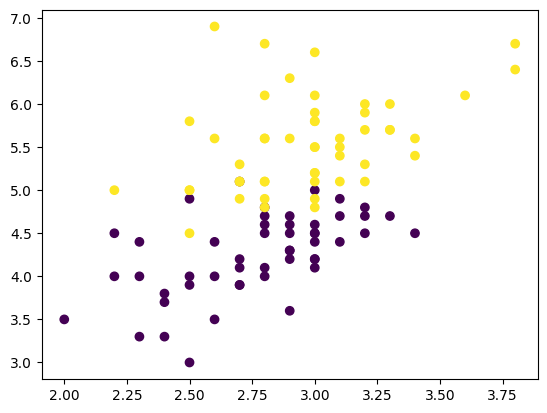

In [80]:
plt.scatter(df['sepal_width'], df['petal_length'], c=df['species'])
plt.show()

In [81]:
df_train = df.iloc[:60, :].sample(10)
df_train

,sepal_width,petal_length,species
68,2.2,4.5,1
70,3.2,4.8,1
83,2.7,5.1,1
75,3.0,4.4,1
108,2.5,5.8,2
103,2.9,5.6,2
92,2.6,4.0,1
102,3.0,5.9,2
86,3.1,4.7,1
106,2.5,4.5,2


In [82]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

y_test

array([1, 2, 2, 2, 1])

# **Bagging**

In [83]:
from mlxtend.plotting import plot_decision_regions

def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.show()
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

0.9


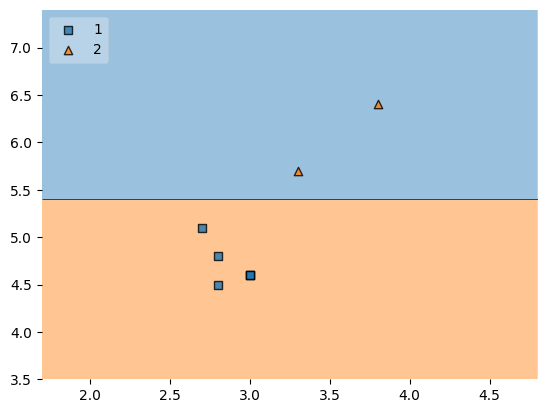

0.8


In [84]:
df_bag = df_train.sample(8, replace=True)

X = df_bag.iloc[:, 0:2]
y = df_bag.iloc[:, -1]

dt_bag1 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag1, X, y, cv=5)))
evaluate(dt_bag1, X, y)

0.9


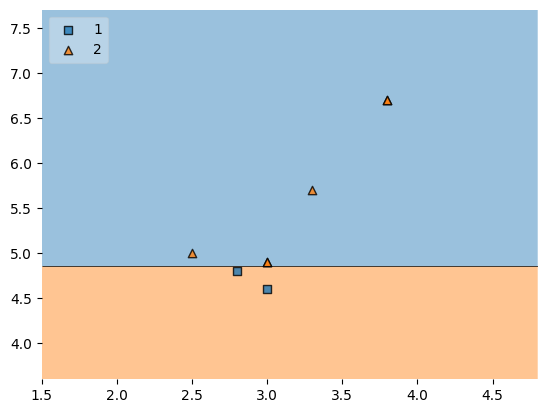

1.0


In [85]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

dt_bag2 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag2, X, y, cv=5)))
evaluate(dt_bag2,X,y)

1.0


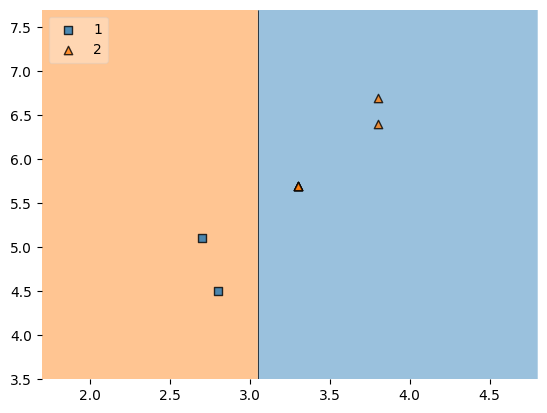

0.4


In [86]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]


dt_bag3 = DecisionTreeClassifier()
print(np.mean(cross_val_score(dt_bag3, X, y, cv=5)))
evaluate(dt_bag3,X,y)

# **Prediction using Bagging**

In [87]:
print(f"Predictor 1 : {dt_bag1.predict(np.array([2.2, 5.0]).reshape(1, 2))}")
print(f"Predictor 2 : {dt_bag2.predict(np.array([2.2, 5.0]).reshape(1, 2))}")
print(f"Predictor 3 : {dt_bag3.predict(np.array([2.2, 5.0]).reshape(1, 2))}")

Predictor 1 : [1]
Predictor 2 : [2]
Predictor 3 : [1]
